In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

                      Attribute Mercury    Venus  Earth   Moon   Mars  \
0                Mass (10^24kg)   0.330     4.87   5.97  0.073  0.642   
1                 Diameter (km)    4879    12104  12756   3475   6792   
2              Density (kg/m^3)    5429     5243   5514   3340   3934   
3               Gravity (m/s^2)     3.7      8.9    9.8    1.6    3.7   
4        Escape Velocity (km/s)     4.3     10.4   11.2    2.4    5.0   
5       Rotation Period (hours)  1407.6  -5832.5   23.9  655.7   24.6   
6         Length of Day (hours)  4222.6   2802.0   24.0  708.7   24.7   
7   Distance from Sun (10^6 km)    57.9    108.2  149.6  0.384  228.0   
8          Perihelion (10^6 km)    46.0    107.5  147.1  0.363  206.7   
9            Aphelion (10^6 km)    69.8    108.9  152.1  0.406  249.3   
10        Orbital Period (days)    88.0    224.7  365.2   27.3  687.0   
11      Orbital Velocity (km/s)    47.4     35.0   29.8    1.0   24.1   
12    Orbital Inclination (deg)     7.0      3.4   

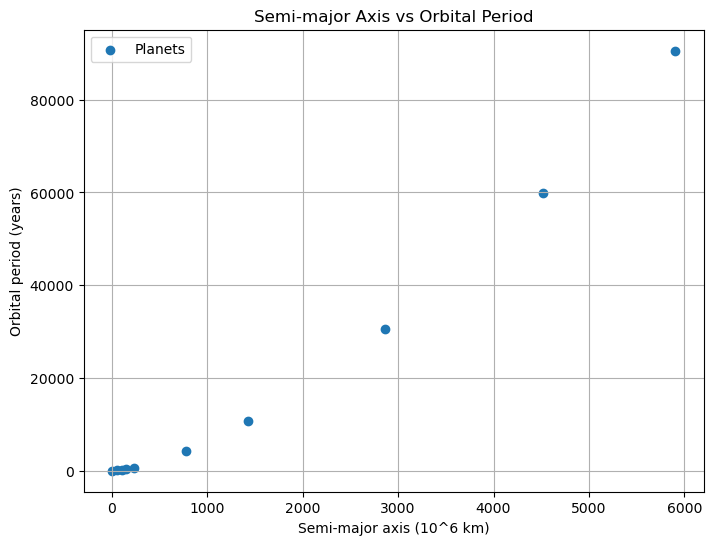

Best-fit parameter m: 0.19879981918623565
Fit: T = 0.20 * a^(3/2)
Reduced chi-squared: 41276.70608939402


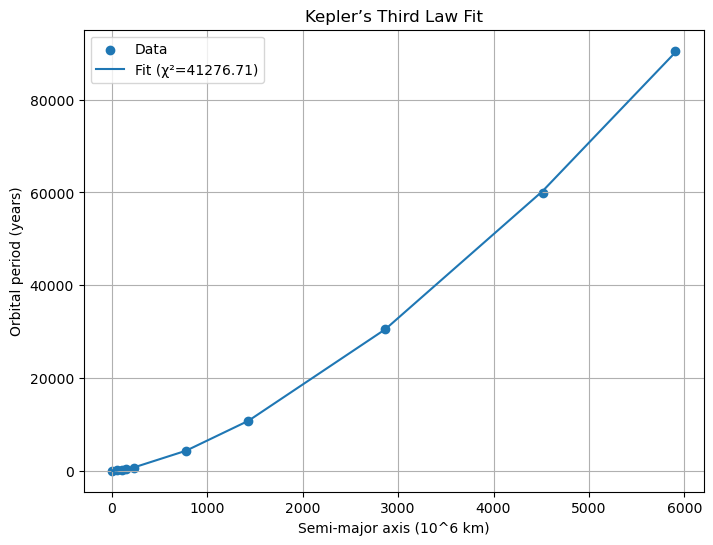

In [27]:
# -- 3: Kepler's Third Law --
# 3)
df = pd.read_csv("../../course_assignments/homework9/solar_system.csv")
print(df)

# 4)
# The shape is (20, 11)
# There are 22 rows and 11 columns
print(df.head(5))
print(df.tail(5))
print(df.columns)
print(list(df.index))

# 5)
perihelion = df.iloc[8, 1:].astype(float)
aphelion = df.iloc[9, 1:].astype(float)
orbital_period = df.iloc[10, 1:].astype(float)

# 6)
# Perihelion is where the object is closest to the Sun in its orbit.
# Aphelion is where the object is farthest from the Sun in its orbit.
# Semi-major axis is half of the longest diameter in an ellipse, so the perihelion plus the aphelion divided by 2.

# 7)
semi_major_axis = (perihelion + aphelion) / 2

# 8)
semi_major_series = pd.Series(semi_major_axis, name="Semi-major axis (AU)")
df = pd.concat([df, semi_major_series])
print(df)

# 9)
print(df.shape)
# There are 30 rows and 12 columns

# 10)
plt.figure(figsize=(8, 6))
plt.scatter(semi_major_axis, orbital_period, label="Planets")
plt.xlabel("Semi-major axis (10^6 km)")
plt.ylabel("Orbital period (years)")
plt.title("Semi-major Axis vs Orbital Period")
plt.legend()
plt.grid(True)
plt.show()

# 11)
def keplers_third_law(a, m):
    return m * a ** 1.5

# 12)
a_vals = semi_major_axis.values.astype(float)
T_vals = orbital_period.values.astype(float)
popt, pcov = curve_fit(keplers_third_law, a_vals, T_vals)
m_fit = popt[0]

# 13)
m_fit = popt[0]
print("Best-fit parameter m:", m_fit)

# 14)
print(f"Fit: T = {m_fit:.2f} * a^(3/2)")

# 15)
residuals = T_vals - keplers_third_law(a_vals, m_fit)
chi2 = np.sum(residuals**2)
dof = len(a_vals) - len(popt)
chi2_reduced = chi2 / dof
print("Reduced chi-squared:", chi2_reduced)

# 16)
plt.figure(figsize=(8, 6))
plt.scatter(a_vals, T_vals, label="Data")
plt.plot(a_vals, keplers_third_law(a_vals, m_fit),
         label=f"Fit (χ²={chi2_reduced:.2f})")
plt.xlabel("Semi-major axis (10^6 km)")
plt.ylabel("Orbital period (years)")
plt.title("Kepler’s Third Law Fit")
plt.legend()
plt.grid(True)
plt.show()

# 17)
df.to_csv("kepler.csv", index=False)